In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn import tree

In [2]:
df= pd.read_csv('C:\\Users\\HP\\Downloads\\LWDcHJitQTqoxAFD3h1K_housing - Hart Ofigwe.csv.xls')

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
# Drop missing values
df = df.dropna()

# Features and target
X = df[['longitude', 'latitude', 'housing_median_age', 'total_rooms',
        'total_bedrooms', 'population', 'households', 'median_income']]

y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# Create and train the Decision Tree Regressor
dt_regressor = DecisionTreeRegressor( max_depth=10, min_samples_split=20, min_samples_leaf=10,    
    random_state=42)

dt_regressor.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=10, min_samples_leaf=10, min_samples_split=20,
                      random_state=42)

In [7]:
# Make predictions for the tain dataset
y_pred_train = dt_regressor.predict(X_train)
print(y_pred_train)

[221870.29245283 102065.13409962 244037.13100437 ... 345400.
 261352.63157895 251872.72727273]


In [8]:
# Create a DataFrame for actual vs predicted values on the train set
results_df = pd.DataFrame({'Actual': y_train, 'Predicted': y_pred_train})
display(results_df.head(10))

,Actual,Predicted
17727,227600.0,221870.292453
2057,110400.0,102065.134100
6453,248100.0,244037.131004
4619,305600.0,375100.250000
15266,214600.0,231400.897436
6823,227300.0,202709.318707
8384,177200.0,181845.454545
2758,84700.0,64100.000000
18143,451400.0,409121.714286
15621,500001.0,424580.400000


In [9]:
# Make predictions for the test dataset
y_pred_test = dt_regressor.predict(X_test)
print(y_pred_test)

[215201.53030303 188709.375      202709.3187067  ...  79421.76470588
 113330.76923077 131809.5505618 ]


In [10]:
# Create a DataFrame for actual vs predicted values on the test set
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_test})
display(results_df.head(10))

,Actual,Predicted
14416,245800.0,215201.530303
16383,137900.0,188709.375000
7731,218200.0,202709.318707
1410,220800.0,112925.352113
1335,170500.0,158175.342466
16260,75000.0,91215.862069
18011,269400.0,302928.607143
10086,228900.0,202709.318707
18294,500001.0,458230.200000
18733,80800.0,64023.865672


In [11]:
# Calculate metrics
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

print("Training R² Score:", round(train_r2, 4))
print("Test R² Score:", round(test_r2, 4))

print("Training MAE:", round(train_mae, 2))
print("Test MAE:", round(test_mae, 2))

Training R² Score: 0.8054
Test R² Score: 0.7312
Training MAE: 34361.28
Test MAE: 40685.62


In [12]:
average_house_price = df['median_house_value'].mean()
MAE_percentage_of_avg = (test_mae / average_house_price) * 100

print(round(MAE_percentage_of_avg, 2))

19.67


In [13]:
# Feature importance
feature_importance = pd.DataFrame({'feature': X.columns,
    'importance': dt_regressor.feature_importances_}).sort_values('importance', ascending=False)
display(feature_importance)

,feature,importance
7,median_income,0.597315
0,longitude,0.171375
1,latitude,0.149376
2,housing_median_age,0.052824
5,population,0.011115
6,households,0.006720
4,total_bedrooms,0.006472
3,total_rooms,0.004802


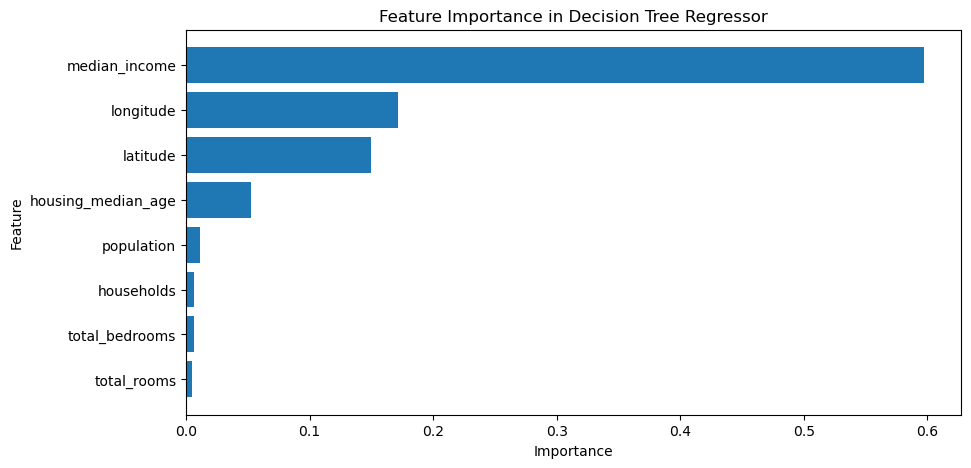

In [14]:
sorted_importance = feature_importance.sort_values(by = 'importance', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(sorted_importance['feature'], sorted_importance['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Decision Tree Regressor')
plt.show()

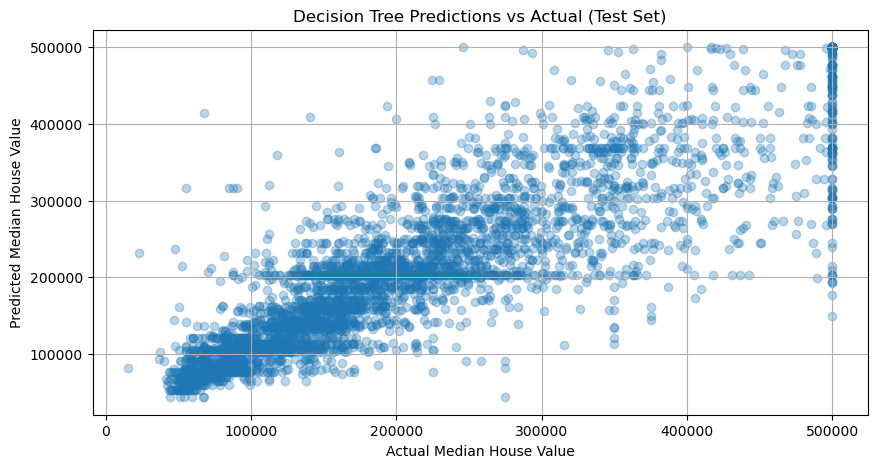

In [15]:
# Plot actual vs predicted values for the testing set
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_test, alpha=0.3)
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Decision Tree Predictions vs Actual (Test Set)")
plt.grid(True)
plt.show()

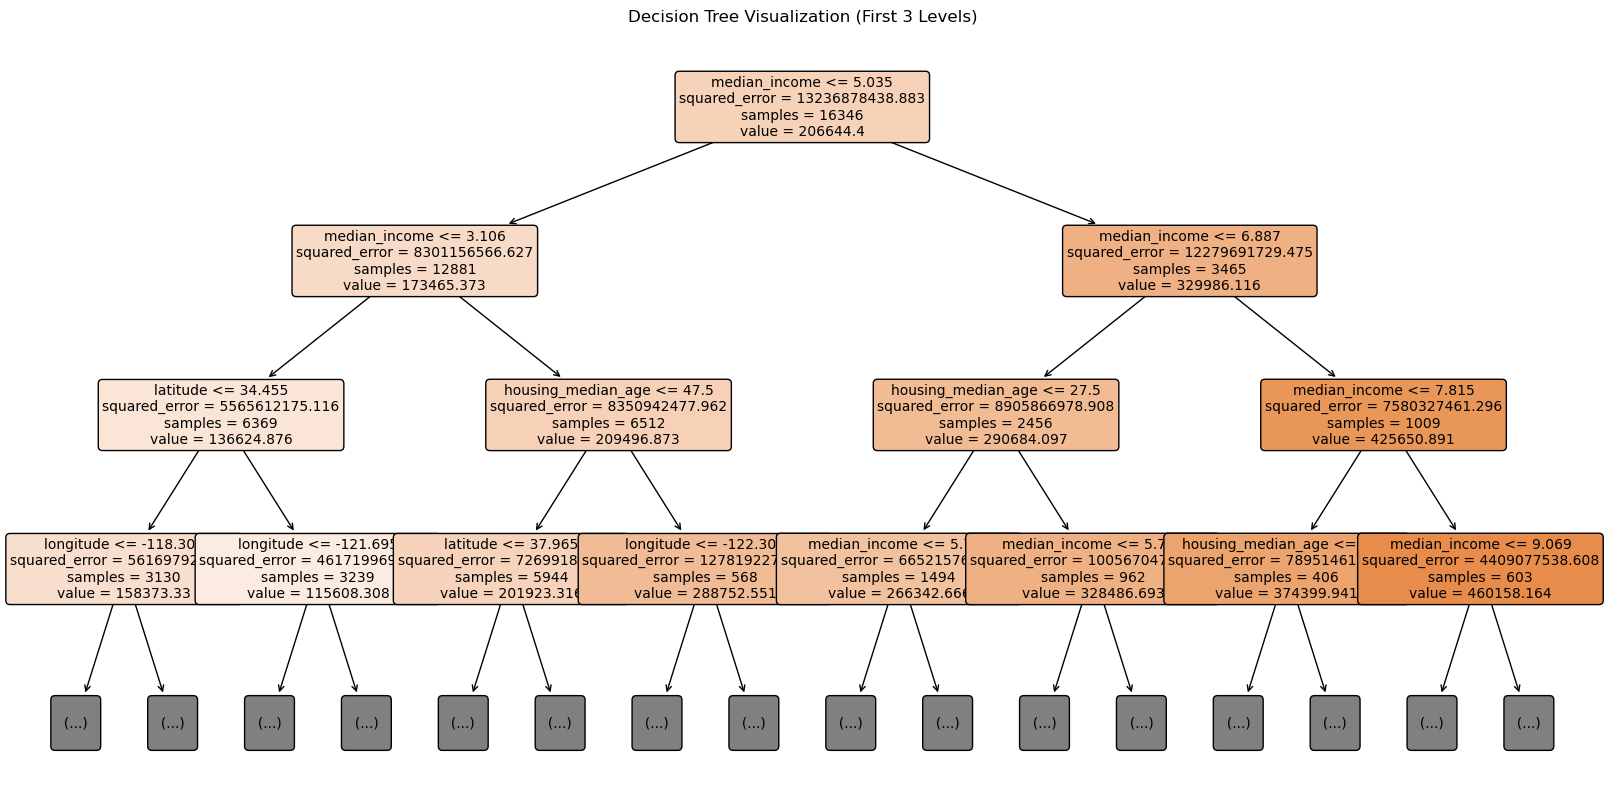

In [16]:
# Visualize a small portion of the tree (first few levels)

plt.figure(figsize=(20, 10))
features = X.columns
tree.plot_tree(dt_regressor, feature_names=features, max_depth=3, filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree Visualization (First 3 Levels)')
plt.show()

In [17]:
from sklearn.ensemble import RandomForestRegressor

In [18]:
# Create and train the Random Forest Regressor
rf_regressor = RandomForestRegressor(
    n_estimators=100,      # Number of decision trees in the forest
    max_depth=10,          # Limit depth of each tree
    min_samples_split=20,  # Minimum samples required to split a node
    min_samples_leaf=10,   # Minimum samples required at a leaf node
    random_state=42,
    n_jobs=-1              # Use all available CPU cores
)

rf_regressor.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=10, min_samples_split=20,
                      n_jobs=-1, random_state=42)

In [19]:
# Make predictions for the training dataset
y_pred_train_rf = rf_regressor.predict(X_train)

# Make predictions for the test dataset
y_pred_test_rf = rf_regressor.predict(X_test)

# Display some predictions
print("Random Forest Predictions (Training Set - first 10):")
print(y_pred_train_rf[:10])
print("\nRandom Forest Predictions (Test Set - first 10):")
print(y_pred_test_rf[:10])

Random Forest Predictions (Training Set - first 10):
[216534.96260459  97163.19512959 221245.70442977 286921.92884375
 244872.36226747 218501.23428459 179612.66683133  61708.14104986
 382927.01806245 430168.21898946]

Random Forest Predictions (Test Set - first 10):
[217587.68915278 152771.41918261 202025.04936587 128884.40126139
 153722.38744376  86701.72974158 284277.31518629 207726.00690327
 466491.15679752  69880.1837787 ]


In [20]:
# Evaluate Random Forest model
results_df = pd.DataFrame({'Actual': y_train, 'Predicted': y_pred_train})
display(results_df.head(10))


results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_test})
display(results_df.head(10))

,Actual,Predicted
17727,227600.0,221870.292453
2057,110400.0,102065.134100
6453,248100.0,244037.131004
4619,305600.0,375100.250000
15266,214600.0,231400.897436
6823,227300.0,202709.318707
8384,177200.0,181845.454545
2758,84700.0,64100.000000
18143,451400.0,409121.714286
15621,500001.0,424580.400000


,Actual,Predicted
14416,245800.0,215201.530303
16383,137900.0,188709.375000
7731,218200.0,202709.318707
1410,220800.0,112925.352113
1335,170500.0,158175.342466
16260,75000.0,91215.862069
18011,269400.0,302928.607143
10086,228900.0,202709.318707
18294,500001.0,458230.200000
18733,80800.0,64023.865672


In [21]:
# Feature importance for Random Forest
rf_train_r2 = r2_score(y_train, y_pred_train_rf)
rf_test_r2 = r2_score(y_test, y_pred_test_rf)

rf_train_mae = mean_absolute_error(y_train, y_pred_train_rf)
rf_test_mae = mean_absolute_error(y_test, y_pred_test_rf)

print("Training R² Score:", round(rf_train_r2, 4))
print("Test R² Score:", round(rf_test_r2, 4))

print("Training MAE:", round(rf_train_mae, 2))
print("Test MAE:", round(rf_test_mae, 2))

Training R² Score: 0.8308
Test R² Score: 0.7791
Training MAE: 31872.57
Test MAE: 36640.07


In [22]:
average_house_price = df['median_house_value'].mean()
MAE_percentage_of_avg = (rf_test_mae / average_house_price) * 100

print(round(MAE_percentage_of_avg, 2))

17.71


In [23]:
# Feature importance for Random Forest
rf_feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_regressor.feature_importances_
}).sort_values('importance', ascending=False)

display(rf_feature_importance)

,feature,importance
7,median_income,0.601485
0,longitude,0.161497
1,latitude,0.146397
2,housing_median_age,0.054576
5,population,0.012380
4,total_bedrooms,0.011139
3,total_rooms,0.006672
6,households,0.005855


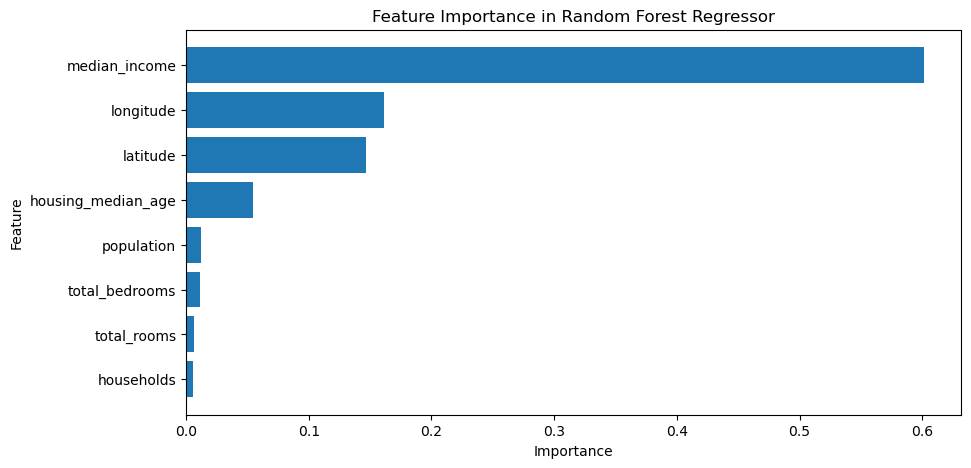

In [24]:
sorted_importance_rf = rf_feature_importance.sort_values(by = 'importance', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(sorted_importance_rf['feature'], sorted_importance_rf['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Random Forest Regressor')
plt.show()

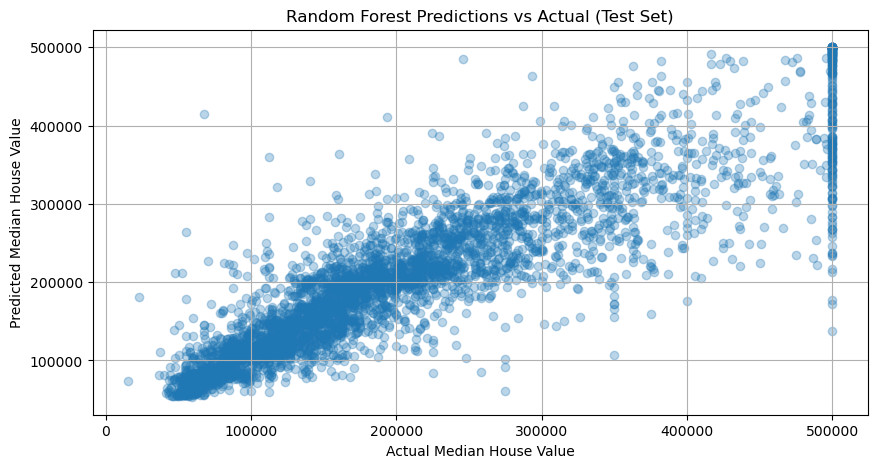

In [25]:
# Plot actual vs predicted values for the testing set (Random Forest)
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_test_rf, alpha=0.3)
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Random Forest Predictions vs Actual (Test Set)")
plt.grid(True)
plt.show()

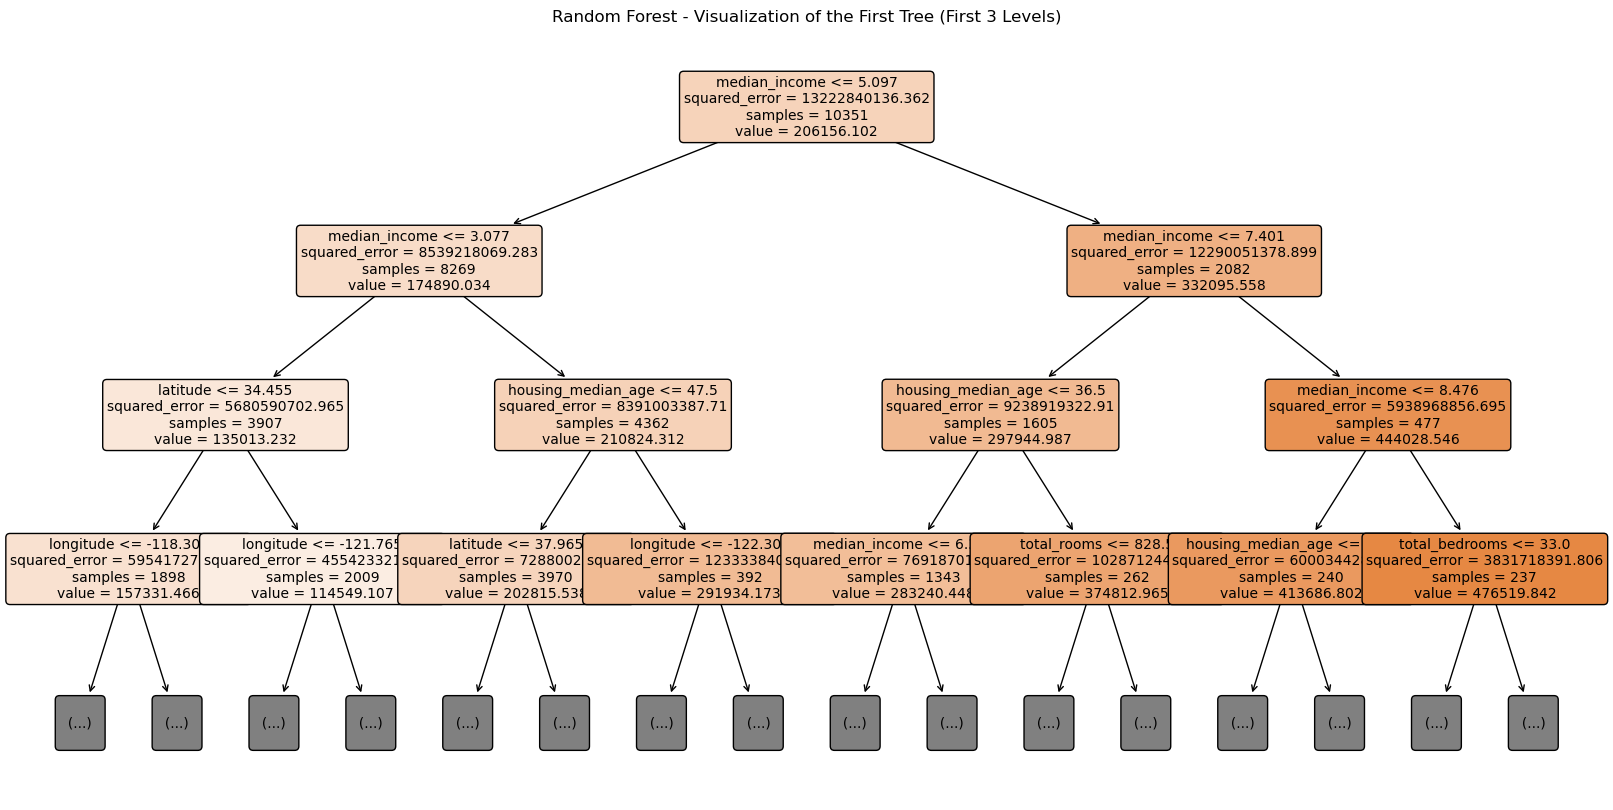

In [26]:
plt.figure(figsize=(20, 10))
features = X.columns

# Access the first estimator (tree) from the Random Forest
# You can change the index ([0], [1], etc.) to view different trees

tree.plot_tree(rf_regressor.estimators_[0],
               feature_names=features,
               max_depth=3,
               filled=True,
               rounded=True,
               fontsize=10)
plt.title('Random Forest - Visualization of the First Tree (First 3 Levels)')
plt.show()